In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [ ]:
df = pd.read_csv('data.csv')
df.shape

(11500, 180)

In [ ]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [ ]:
df.count()

,0
Unnamed: 0,11500
X1,11500
X2,11500
X3,11500
X4,11500
...,...
X175,11500
X176,11500
X177,11500
X178,11500


In [ ]:
X_raw = df.drop(columns=[c for c in ['y', 'Unnamed: 0'] if c in df.columns]).values
X_raw

array([[ 135,  190,  229, ..., -116,  -83,  -51],
       [ 386,  382,  356, ...,  154,  143,  129],
       [ -32,  -39,  -47, ...,  -35,  -35,  -36],
       ...,
       [  14,    6,  -13, ...,   -2,   -1,   -8],
       [ -40,  -25,   -9, ...,   68,   59,   55],
       [  29,   41,   57, ...,   -2,    2,   20]])

In [ ]:
y = df['y'].values
y_4class = []
for label in y:
    if label == 1:        # Set E (Seizure) -> 0
        y_4class.append(0)
    elif label in [2, 3]: # Set C & D (Pathological) -> 1
        y_4class.append(1)
    elif label == 4:      # Set B (Healthy-Closed) -> 2
        y_4class.append(2)
    else:                 # Set A (Healthy-Open) -> 3
        y_4class.append(3)

y_4class = np.array(y_4class)
y_4class

array([2, 0, 3, ..., 3, 1, 2])

In [ ]:
def create_spectrograms(data):
    specs = []
    for sig in data:
        # Standardize signal
        sig_n = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

        # Compute Spectrogram
        # nperseg=32 and noverlap=16 create a roughly 17x11 image for this 178-pt signal
        f, t, Sxx = spectrogram(sig_n, fs=178, nperseg=32, noverlap=24)

        # Log-scale to highlight subtle differences in C vs D
        # We add a small constant to avoid log(0)
        spec_log = np.log(Sxx + 1e-10)
        specs.append(spec_log)

    return np.array(specs)

In [ ]:
print("Converting 1D Waves into 2D Spectral Images...")
X_2d = create_spectrograms(X_raw)

# Reshape for 2D CNN: (Samples, Height, Width, Channels)
X_2d = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], X_2d.shape[2], 1)

Converting 1D Waves into 2D Spectral Images...


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_4class, test_size=0.2, random_state=42)

In [ ]:
def build_4class_2d_monitor(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Global Pooling to prevent overfitting
        layers.GlobalAveragePooling2D(),

        # Decision Head
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.02)),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax') # 4 Output neurons
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
model = build_4class_2d_monitor((X_2d.shape[1], X_2d.shape[2], 1))

In [ ]:
print("Training the 4-Class 2D Spectral Monitor...")
history = model.fit(
    X_train, y_train,
    epochs=120,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

Training the 4-Class 2D Spectral Monitor...
Epoch 1/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7652 - loss: 1.6632 - val_accuracy: 0.7765 - val_loss: 1.1990 - learning_rate: 5.0000e-04
Epoch 2/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8616 - loss: 0.6937 - val_accuracy: 0.8370 - val_loss: 0.6273 - learning_rate: 5.0000e-04
Epoch 3/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8749 - loss: 0.4760 - val_accuracy: 0.8791 - val_loss: 0.4056 - learning_rate: 5.0000e-04
Epoch 4/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8822 - loss: 0.3948 - val_accuracy: 0.8557 - val_loss: 0.4287 - learning_rate: 5.0000e-04
Epoch 5/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8899 - loss: 0.3550 - val_accuracy: 0.8613 - val_loss: 0.4163 - learning_rate: 5.0000e-04
Epoch 6/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8955 - loss: 0.3298 - val_accuracy: 0.8170 - val_loss: 0.4802 - learning_rate: 5.0000e-04
Epoch 7/120


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                precision    recall  f1-score   support

       Seizure       0.98      0.95      0.97       465
  Pathological       0.93      0.97      0.95       909
Healthy-Closed       0.88      0.90      0.89       457
  Healthy-Open       0.87      0.80      0.83       469

      accuracy                           0.92      2300
     macro avg       0.92      0.91      0.91      2300
  weighted avg       0.92      0.92      0.92      2300



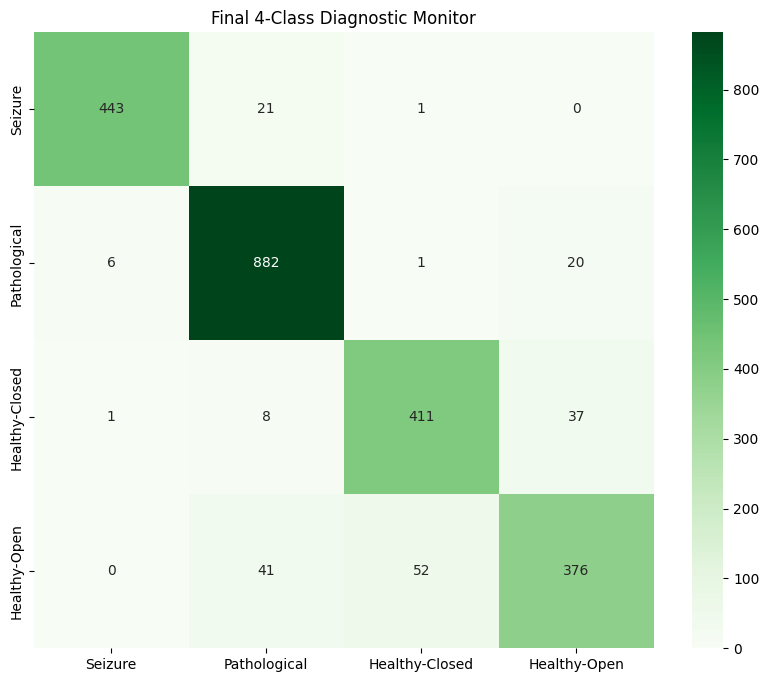

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
class_names = ['Seizure', 'Pathological', 'Healthy-Closed', 'Healthy-Open']

print(classification_report(y_test, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final 4-Class Diagnostic Monitor')
plt.show()

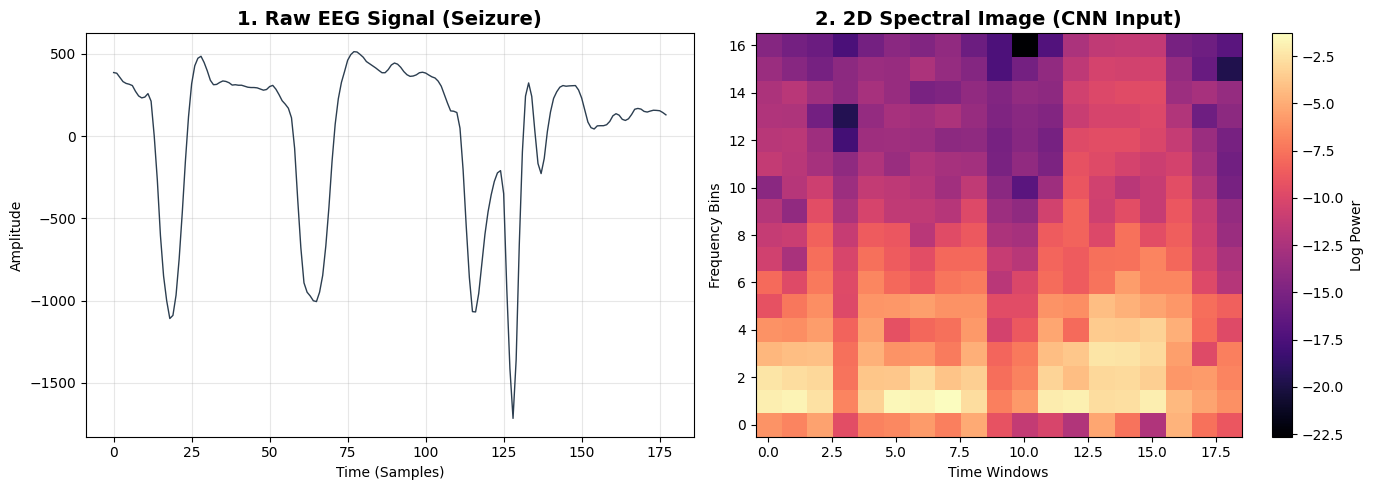

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_comparison_plot(X_raw_sample, X_2d_sample, label_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Plot the Raw 1D Signal
    ax1.plot(X_raw_sample, color='#2c3e50', linewidth=1)
    ax1.set_title(f"1. Raw EEG Signal ({label_name})", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Time (Samples)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)

    # 2. Plot the 2D Spectrogram
    # Squeeze the (17, 11, 1) to (17, 11) for plotting
    img = ax2.imshow(X_2d_sample.squeeze(), aspect='auto', origin='lower', cmap='magma')
    ax2.set_title(f"2. 2D Spectral Image (CNN Input)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Time Windows")
    ax2.set_ylabel("Frequency Bins")
    plt.colorbar(img, ax=ax2, label='Log Power')

    plt.tight_layout()
    plt.savefig('before_after_transformation.png', dpi=300)
    plt.show()

# Example: Plotting a Seizure sample (Class 0)
# Replace 'X_raw' and 'X_2d' with your variable names
sample_idx = np.where(y_4class == 0)[0][0]
generate_comparison_plot(X_raw[sample_idx], X_2d[sample_idx], "Seizure")

In [ ]:
# Save the entire model to a single file
model.save('eeg_spectral_monitor_92.keras')
print("Model saved successfully!")

Model saved successfully!


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


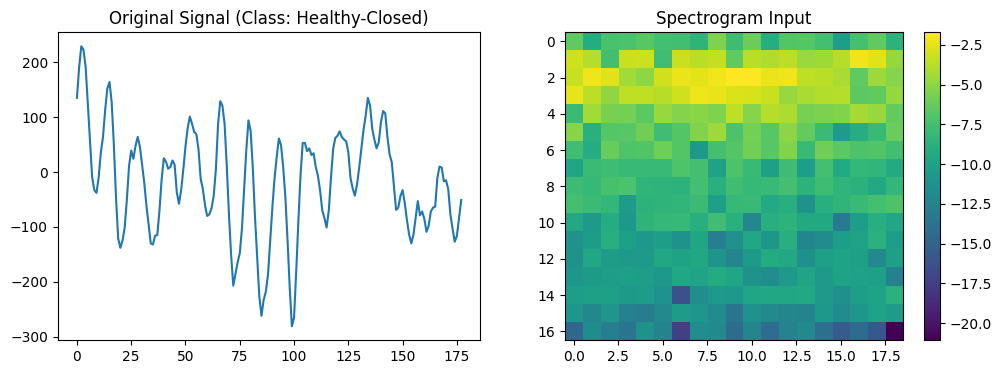

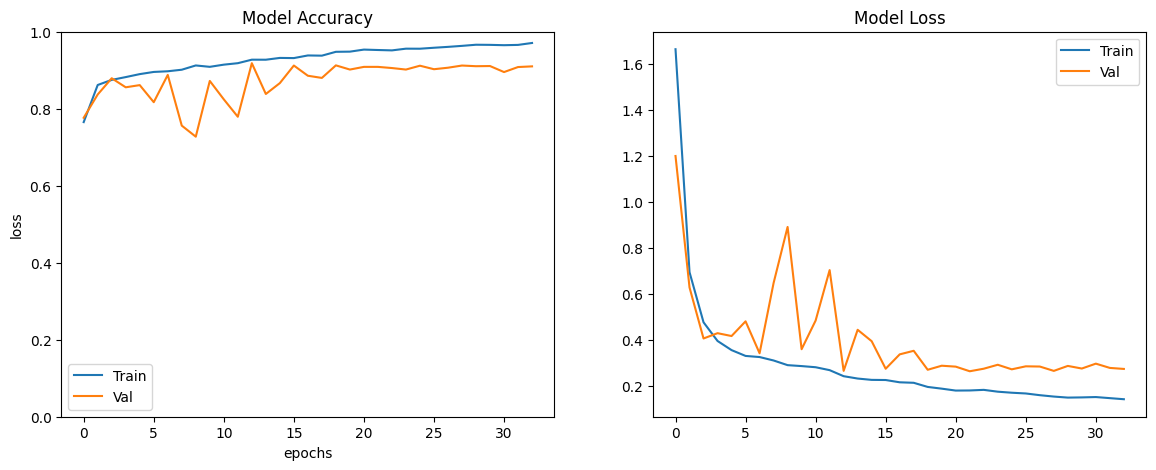

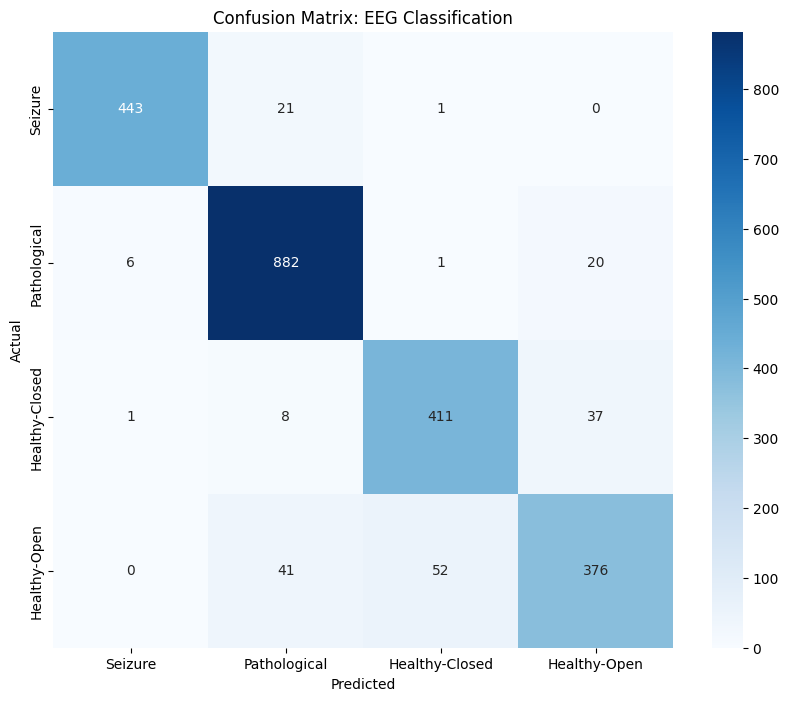

                precision    recall  f1-score   support

       Seizure       0.98      0.95      0.97       465
  Pathological       0.93      0.97      0.95       909
Healthy-Closed       0.88      0.90      0.89       457
  Healthy-Open       0.87      0.80      0.83       469

      accuracy                           0.92      2300
     macro avg       0.92      0.91      0.91      2300
  weighted avg       0.92      0.92      0.92      2300



In [ ]:
# 5. VISUALIZATION SUITE

# A. Training History Plot
def plot_training_history(hist):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(hist.history['accuracy'], label='Train')
    ax1.plot(hist.history['val_accuracy'], label='Val')
    ax1.set_ylim(0, 1)
    ax1.set_title('Model Accuracy')
    ax1.legend()

    ax2.plot(hist.history['loss'], label='Train')
    ax2.plot(hist.history['val_loss'], label='Val')
    ax2.set_title('Model Loss')
    ax2.legend()
    plt.savefig('training_history_plot.png')
    plt.show()

# B. Sample Visualizer
def plot_sample_conversion(idx):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(X_raw[idx])
    plt.title(f"Original Signal (Class: {class_names[y_4class[idx]]})")

    plt.subplot(1, 2, 2)
    plt.imshow(X_2d[idx].reshape(X_2d.shape[1], X_2d.shape[2]), aspect='auto', cmap='viridis')
    plt.title("Spectrogram Input")
    plt.colorbar()
    plt.show()

# C. Confusion Matrix & Report
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: EEG Classification')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()

# EXECUTE PLOTS
plot_sample_conversion(0) # Visualize first sample
plot_training_history(history)
plot_confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=class_names))

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


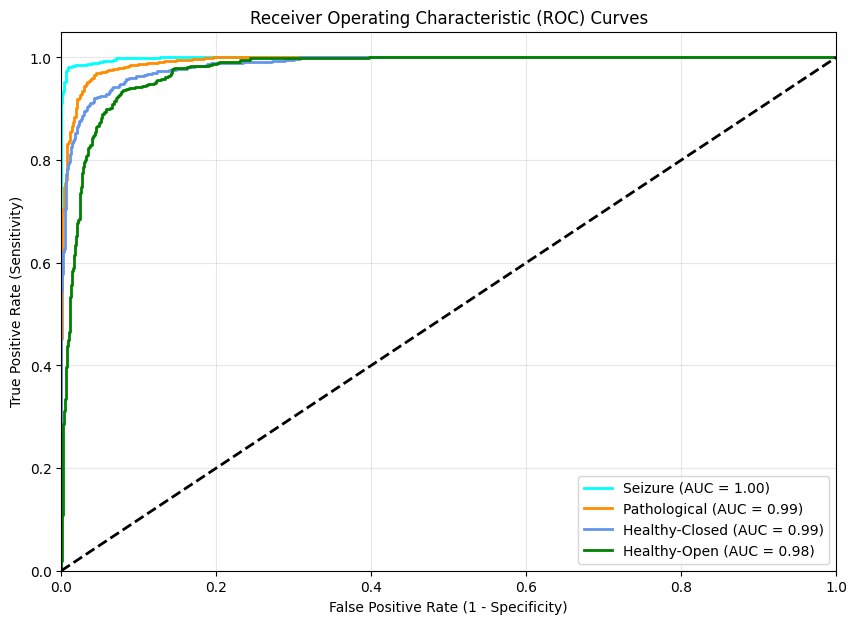

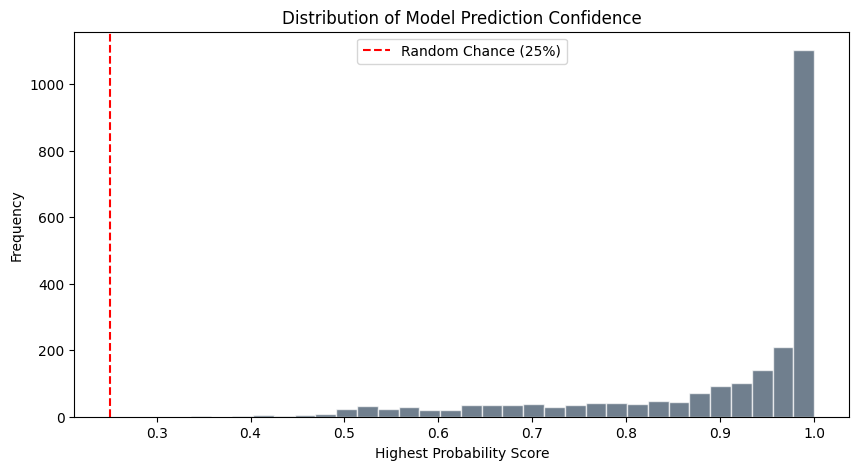

In [ ]:
# --- MISSING IMPORTS ---
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# 1. MULTI-CLASS ROC CURVE
def plot_roc_curve(y_test, y_probs, class_names):
    # Convert labels to binary format for multi-class ROC
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
    n_classes = 4

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 7))
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('roc_curve.png')
    plt.show()

# 3. CONFIDENCE HISTOGRAM
def plot_confidence_hist(y_probs):
    confidences = np.max(y_probs, axis=1)
    plt.figure(figsize=(10, 5))
    plt.hist(confidences, bins=30, color='#34495e', edgecolor='white', alpha=0.7)
    plt.title('Distribution of Model Prediction Confidence')
    plt.xlabel('Highest Probability Score')
    plt.ylabel('Frequency')
    plt.axvline(x=0.25, color='red', linestyle='--', label='Random Chance (25%)')
    plt.legend()
    plt.savefig('conidence_hist.png')
    plt.show()

# --- EXECUTION ---
# Get probabilities
y_probs = model.predict(X_test)

# Generate all plots
plot_roc_curve(y_test, y_probs, class_names)
plot_confidence_hist(y_probs)

Computing t-SNE embeddings (this may take a moment)...


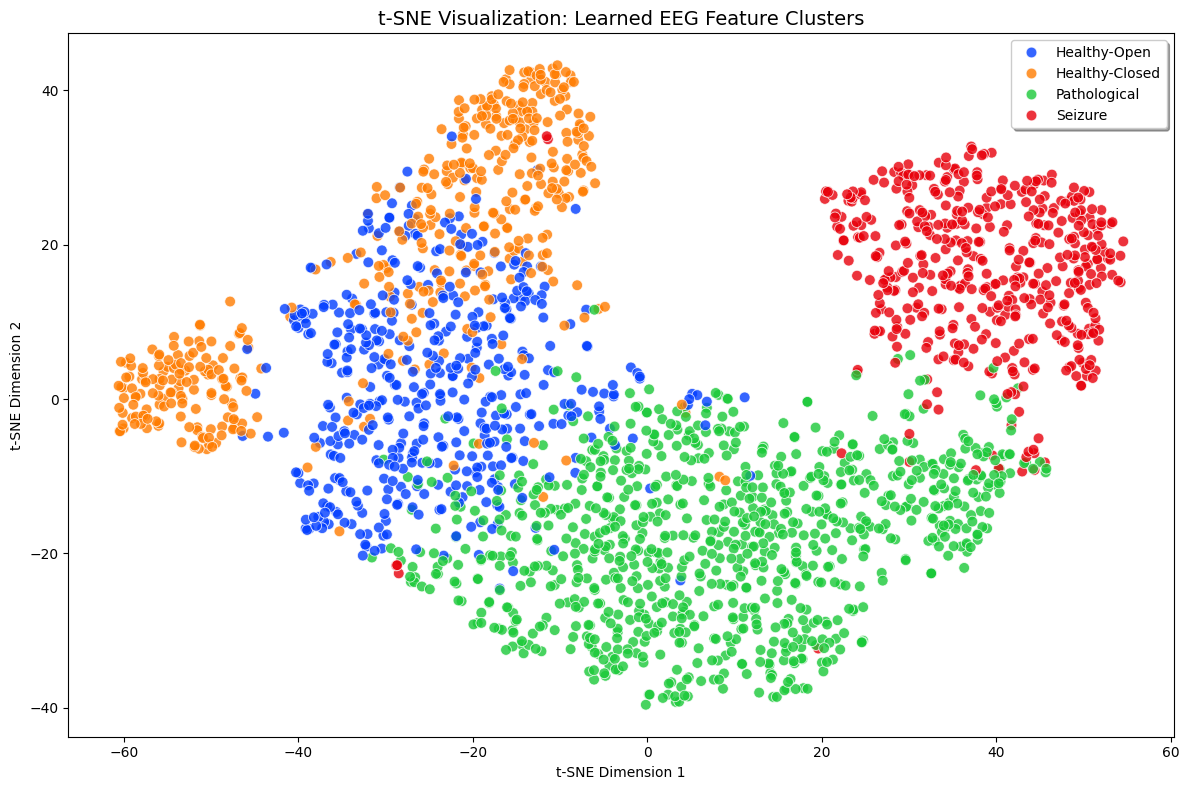

In [ ]:
def plot_tsne_features(model, X_test, y_test, class_names):
    print("Computing t-SNE embeddings (this may take a moment)...")

    # 1. Force the model to realize it has been called
    # We use a dummy prediction to 'initialize' the functional mapping
    _ = model.predict(X_test[:1], verbose=0)

    # 2. Extract features from the GlobalAveragePooling2D layer
    # We find the layer by checking the class type
    layer_output = None
    for layer in model.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            layer_output = layer.output
            break

    if layer_output is None:
        # Fallback if no pooling layer found
        # This line is likely okay, but the previous part of the function was failing
        # because model.input was problematic.
        layer_output = model.layers[-4].output

    # Create the extractor using the model's actual input and the found output
    # FIX: Use model.layers[0].input instead of model.input for robustness
    feature_extractor = models.Model(inputs=model.layers[0].input, outputs=layer_output)
    features = feature_extractor.predict(X_test, verbose=0)

    # 3. Dimensionality Reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_results = tsne.fit_transform(features)

    # 4. Plotting
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=tsne_results[:,0], y=tsne_results[:,1],
        hue=[class_names[i] for i in y_test],
        palette='bright',
        legend='full',
        alpha=0.8,
        s=60
    )
    plt.title('t-SNE Visualization: Learned EEG Feature Clusters', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=10)
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(loc='best', frameon=True, shadow=True, fontsize=10)
    plt.tight_layout()
    plt.savefig('tsne_visualization.png', dpi=300)
    plt.show()

plot_tsne_features(model, X_test, y_test, class_names)

/tmp/ipykernel_1571/2589379661.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=class_names, patch_artist=True,


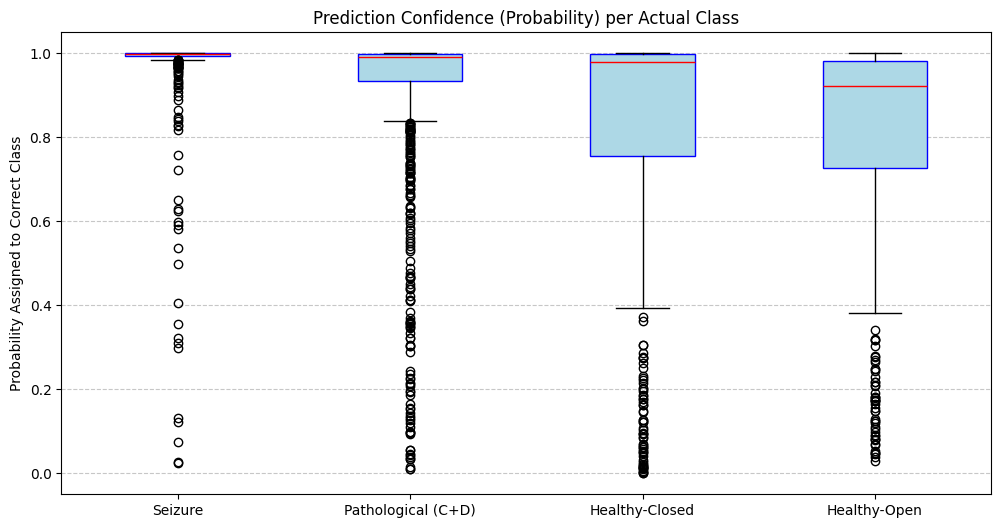

In [ ]:
def plot_class_probability_boxplot(y_test, y_probs, class_names):
    """Shows how strongly the model predicts each class."""
    plt.figure(figsize=(12, 6))

    # Extract the probability assigned to the TRUE class for each sample
    true_class_probs = [y_probs[i, y_test[i]] for i in range(len(y_test))]

    data_to_plot = []
    for i in range(4):
        indices = np.where(y_test == i)[0]
        data_to_plot.append([y_probs[idx, i] for idx in indices])

    plt.boxplot(data_to_plot, labels=class_names, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red'))

    plt.title('Prediction Confidence (Probability) per Actual Class')
    plt.ylabel('Probability Assigned to Correct Class')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Run it
plot_class_probability_boxplot(y_test, y_probs, class_names)